In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns;

In [2]:
df = pd.read_csv("./placement (2).csv")

In [3]:
df.shape

(1000, 3)

In [4]:
df.sample(5)

,cgpa,placement_exam_marks,placed
934,7.15,9.0,0
638,7.46,74.0,1
544,7.11,14.0,1
159,6.70,22.0,0
235,7.20,52.0,1


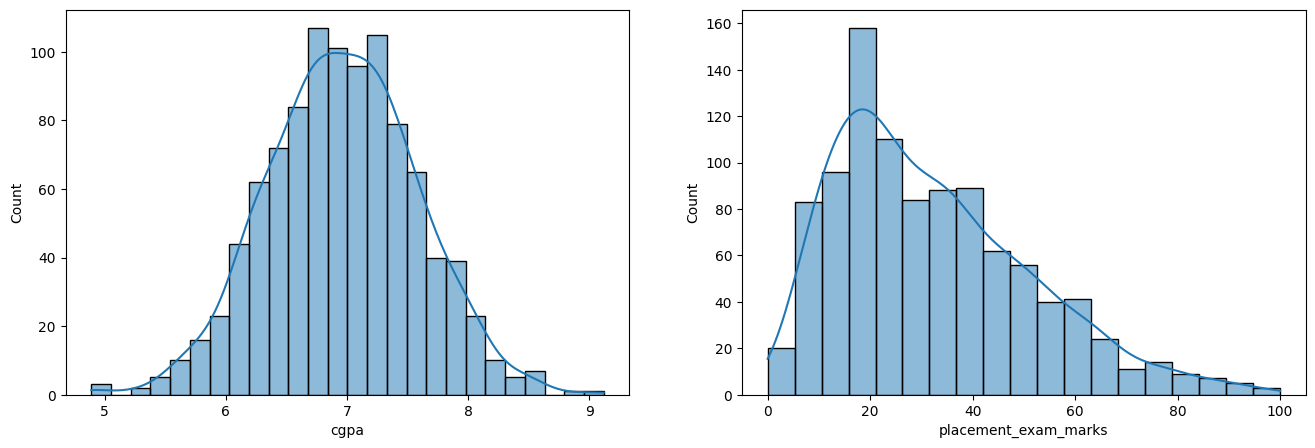

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde=True)

plt.show()

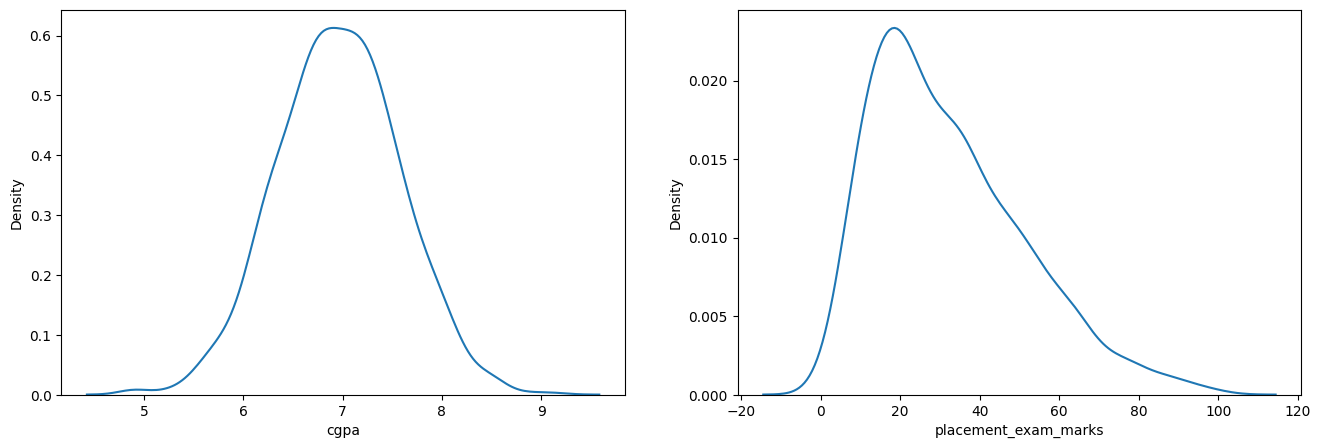

In [6]:
plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
sns.kdeplot(df['cgpa'])

plt.subplot(1,2,2)
sns.kdeplot(df['placement_exam_marks'])

plt.show()

In [7]:
print("Mean value of cgpa : ", df['cgpa'].mean())
print("Std value of cgpa", df['cgpa'].std())
print("Min value of cgpa : ", df['cgpa'].min())
print("Max value of cgpa : ", df['cgpa'].max())

Mean value of cgpa :  6.96124
Std value of cgpa 0.6158978751323896
Min value of cgpa :  4.89
Max value of cgpa :  9.12


In [8]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

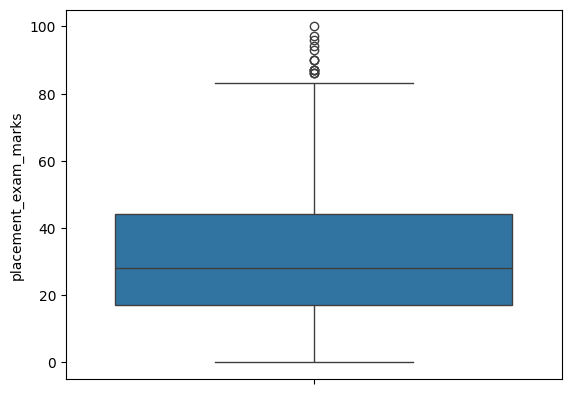

In [9]:
sns.boxplot(df['placement_exam_marks'])

In [11]:
# Finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [12]:
percentile75

np.float64(44.0)

In [13]:
iqr = percentile75 - percentile25

In [14]:
iqr

np.float64(27.0)

In [15]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [16]:
print("Upper limit : ", upper_limit)
print("Lower limit : ",lower_limit)

Upper limit :  84.5
Lower limit :  -23.5


## Finding Outliers

In [17]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [18]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


In [19]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [20]:
new_df.shape

(985, 3)

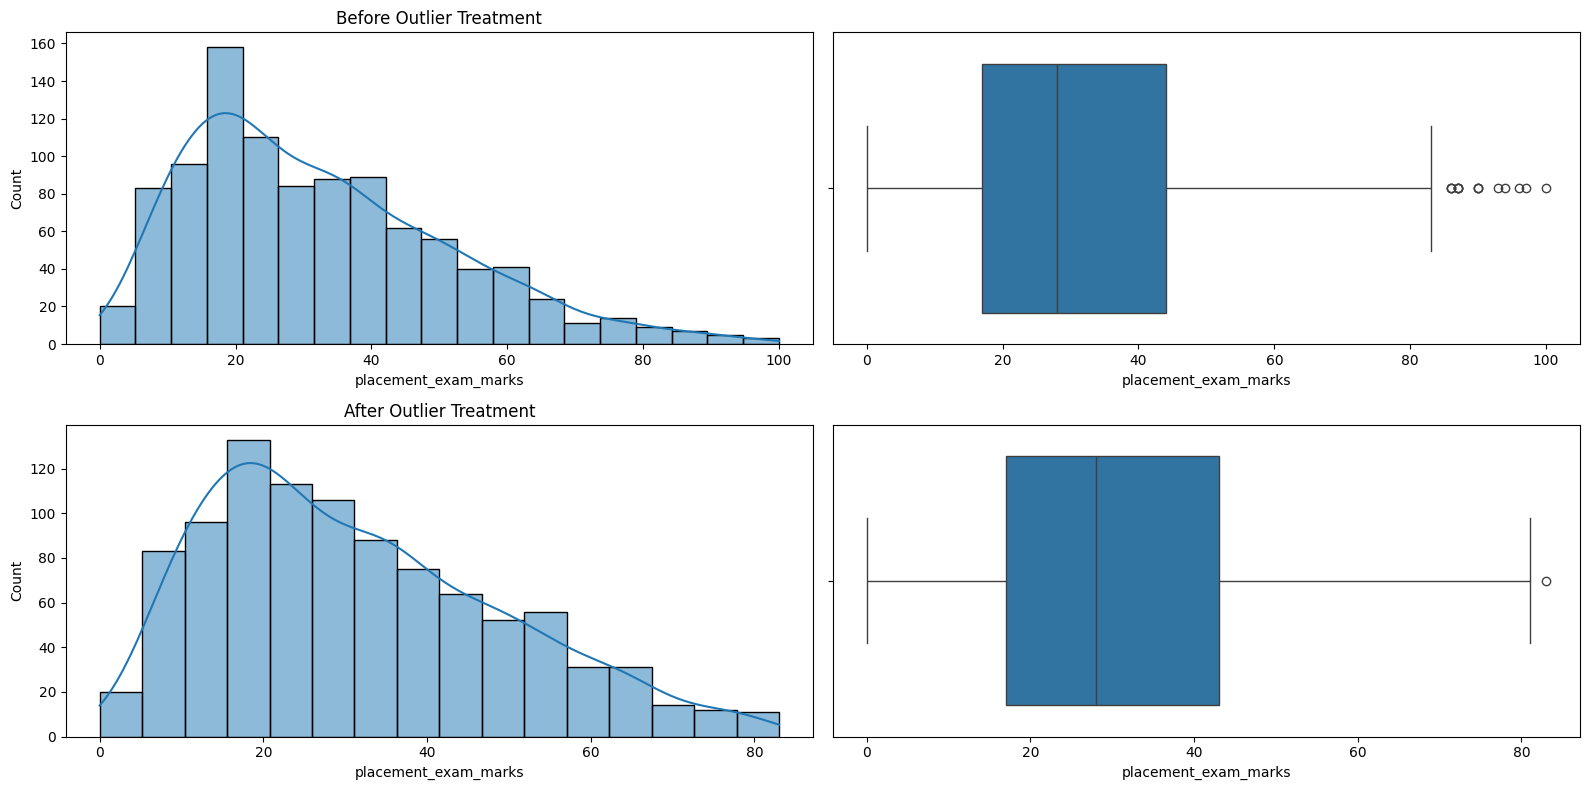

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,8))

plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Before Outlier Treatment')

plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'], kde=True)
plt.title('After Outlier Treatment')

plt.subplot(2,2,4)
sns.boxplot(x=new_df['placement_exam_marks'])

plt.tight_layout()
plt.show()

## Capping

In [23]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [24]:
new_df_cap.shape

(1000, 3)

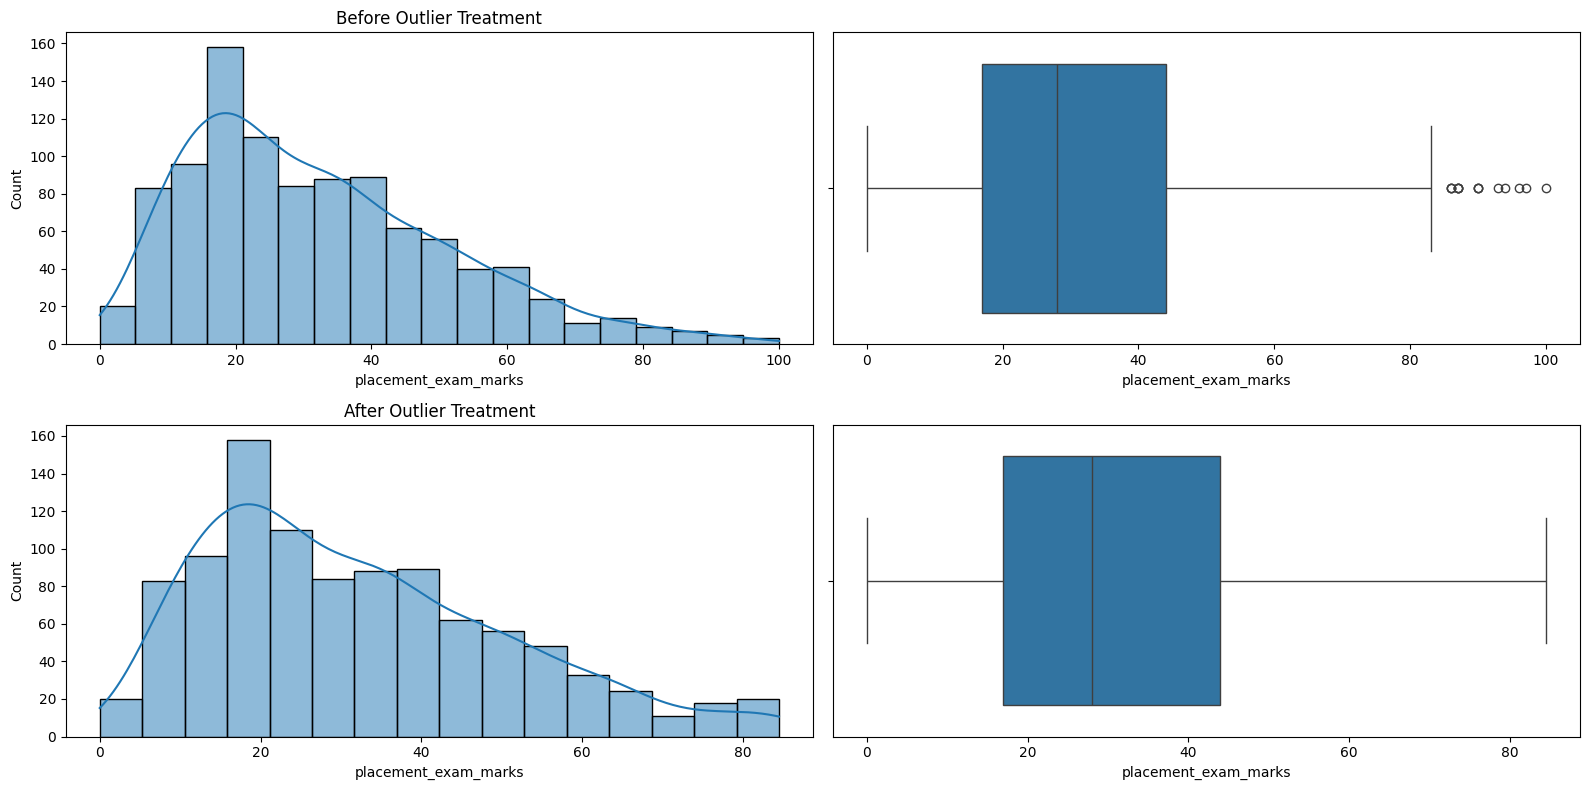

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,8))

plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Before Outlier Treatment')

plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'], kde=True)
plt.title('After Outlier Treatment')

plt.subplot(2,2,4)
sns.boxplot(x=new_df_cap['placement_exam_marks'])

plt.tight_layout()
plt.show()